# N02 - Application: Spin-Chain Quantum Bus
## Virtual tunnelling, selected-mode transport, and remote entanglement

A finite spin chain can mediate a remote interaction, transfer a quantum state, or remain an explicit memory-bearing subsystem. The central modelling decision is therefore which part of its spectrum belongs in the retained slow space:

$$
\boxed{\text{eliminate dispersive modes; retain poles that enter the dynamical window.}}
$$

QuTiP is used for the spin Hilbert space, operator algebra, unitary and dissipative dynamics, reduced states, concurrence, fidelity, and trace distance. The compact one-excitation representation is used only where excitation conservation makes it exact and is checked directly against the tensor-product spin model.

## 1. Motivation and applications

Spin chains provide long-range connectivity without moving the qubits or controlling every intermediate site. The uniform-chain proposal of [Bose (2003)](https://doi.org/10.1103/PhysRevLett.91.207901) established an unmodulated chain as a quantum communication channel, [Christandl *et al.* (2004)](https://doi.org/10.1103/PhysRevLett.92.187902) showed that engineered spectra can produce perfect transfer, and [Wójcik *et al.* (2005)](https://doi.org/10.1103/PhysRevA.72.034303) showed that weak endpoint bonds can turn an otherwise uniform chain into an almost-perfect wire.

This application compares two effective descriptions of the same sender-bus-receiver Hamiltonian. If every appreciably coupled normal mode is off resonance, the bus mediates a direct endpoint interaction while remaining only virtually occupied. This nonlocal-tunnelling regime suppresses exposure to channel imperfections at the price of slower transfer [de Moraes Neto, de Ponte, and Moussa (2011)](https://doi.org/10.1103/PhysRevA.84.032339), [Neto, de Ponte, and Moussa (2012)](https://doi.org/10.1103/PhysRevA.85.052303), and [Almeida (2018)](https://doi.org/10.1103/PhysRevA.98.012334). If one isolated mode approaches resonance, that mode belongs in the retained space; the resulting selected-mode protocol is faster but bus-populating and memory-bearing [Oh *et al.* (2011)](https://doi.org/10.1103/PhysRevA.84.022330), [Lorenzo *et al.* (2013)](https://doi.org/10.1103/PhysRevA.87.042313), [Paganelli *et al.* (2013)](https://doi.org/10.1103/PhysRevA.87.062309), and [Gratsea, Nikolopoulos, and Lambropoulos (2018)](https://doi.org/10.1103/PhysRevA.98.012304). Sender-receiver concurrence is therefore as important as receiver population because the bus can create remote entanglement before completing state transfer [Banchi *et al.* (2010)](https://doi.org/10.1103/PhysRevA.82.052321).

A polarized bus is sufficient for the elementary one-excitation derivation, but it is not universally required. Initialization-free protocols based on endpoint operations and feed-forward [Di Franco, Paternostro, and Kim (2008)](https://doi.org/10.1103/PhysRevLett.101.230502), or on Jordan-Wigner fermions and a two-spin encoding in random unpolarized chains [Yao *et al.* (2011)](https://doi.org/10.1103/PhysRevLett.106.040505), change the encoding and retained structure rather than merely correcting the polarized endpoint Hamiltonian. Recent semiconductor and superconducting experiments make these distinctions directly relevant [Kandel *et al.* (2021)](https://doi.org/10.1038/s41467-021-22416-5), [Xiang *et al.* (2024)](https://doi.org/10.1038/s41467-024-48791-3), and [Roy *et al.* (2025)](https://doi.org/10.1038/s41467-025-57818-2).

## 2. Learning goals and claim-diagnostic map

After completing the notebook, the reader should be able to:

1. diagonalize an open XX bus and identify endpoint weights and mode parity;
2. derive the endpoint-only Hamiltonian by a mode-by-mode small rotation;
3. recover the same result from the boundary resolvent;
4. reconstruct the virtual spatial profile of an eliminated bus;
5. recognize when one mode or a mode cluster must be restored;
6. compare receiver population, concurrence, average transfer fidelity, bus occupation, and endpoint-state distance;
7. distinguish polarized, initialization-free, thermal, disordered, and lossy buses;
8. decide whether the reduced object should be a Hamiltonian, a master equation, or a finite-time channel.

| Physical claim | Primary observable | Required diagnostic | Structural repair |
|---|---|---|---|
| all-mode virtual tunnelling | sender-receiver concurrence and receiver population | $\eta_{\max}$, cumulative dressing, $P_{\rm bus}$, endpoint trace distance | retain the nearest pole if one denominator closes |
| selected-mode transfer | concurrence, receiver population, selected-mode occupation | spectral isolation $\delta_{\rm iso}$ and omitted-mode dressing | retain a mode cluster |
| state transfer rather than population transfer | phase-corrected average fidelity | transferred phase and reduced receiver state | use a channel description |
| lossy virtual bus | fidelity and induced decay matrix | complex boundary self-energy | retain the lossy mode or memory kernel |


## 3. Microscopic model and boundary modes

The sender $S$ and receiver $R$ couple locally to an open $XX$ chain of length $L$,

$$
H=H_{SR}+H_B+V,
$$

$$
H_B=\frac{\omega_B}{2}\sum_{\ell=1}^{L}\sigma_\ell^z
+J_B\sum_{\ell=1}^{L-1}\left(\sigma_\ell^+\sigma_{\ell+1}^-+\mathrm{H.c.}\right),
$$

$$
V=g_S\sigma_S^+\sigma_1^-+g_R\sigma_R^+\sigma_L^-+\mathrm{H.c.}
$$

The code uses the equivalent excitation-number form $\omega_B\sum_\ell n_\ell$, which differs from the $\sigma^z$ form only by an additive constant. For a polarized bus and one transferred excitation, the chain maps exactly to a finite tight-binding problem. The uniform-chain modes are

$$
\varepsilon_k=\omega_B+2J_B\cos\frac{k\pi}{L+1},
\qquad
\phi_k(\ell)=\sqrt{\frac{2}{L+1}}\sin\frac{k\pi\ell}{L+1},
$$

with endpoint couplings $g_{S,k}=g_S\phi_k(1)$ and $g_{R,k}=g_R\phi_k(L)$. The parity relation

$$
\phi_k(L)=(-1)^{k+1}\phi_k(1)
$$

makes the alternating signs of the virtual paths explicit.

### Local-state convention

QuTiP uses

$$
\mathrm{sigmam}=|g\rangle\langle e|,
$$

with `E = basis(2, 0)` and `G = basis(2, 1)`. Hence $\sigma_+\sigma_-=|e\rangle\langle e|$. The tensor-product and one-excitation calculations below use this convention consistently.

In [1]:
from pathlib import Path
import json, logging, platform, shutil, sys
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import scienceplots
import qutip as qt
from IPython.display import Image, display
from qutip import (
    Qobj, basis, qeye, tensor, sigmam, destroy,
    commutator, sesolve, mesolve, expect, ket2dm, concurrence,
    fidelity, tracedist
)

logging.getLogger("fontTools").setLevel(logging.ERROR)
plt.style.use(["science", "notebook"])

# Figure typography and geometry matched to N08.
FIG_WIDTH_150MM = 150.0 / 25.4
SCIPOST_FONT_SIZE = 10.95
plt.rcParams.update({
    "figure.dpi": 150,
    "savefig.dpi": 600,
    "text.usetex": True,
    "font.family": "serif",
    "font.size": SCIPOST_FONT_SIZE,
    "axes.labelsize": SCIPOST_FONT_SIZE,
    "axes.titlesize": SCIPOST_FONT_SIZE,
    "legend.fontsize": SCIPOST_FONT_SIZE,
    "xtick.labelsize": SCIPOST_FONT_SIZE,
    "ytick.labelsize": SCIPOST_FONT_SIZE,
    "axes.linewidth": 0.8,
    "lines.linewidth": 1.35,
    "lines.markersize": 4.2,
    "text.latex.preamble": r"\usepackage{amsmath}",
})

ROOT = Path.cwd()
ASSET_DIR = ROOT / "assets"
FIG_MANUSCRIPT = ROOT / "figures" / "manuscript"
FIG_NOTEBOOK = ROOT / "figures" / "notebook"
DATA_DIR = ROOT / "data"
for directory in (FIG_MANUSCRIPT, FIG_NOTEBOOK, DATA_DIR):
    directory.mkdir(parents=True, exist_ok=True)


SOLVER = {
    "method": "dop853",
    "atol": 1e-10,
    "rtol": 1e-8,
    "nsteps": 30000,
    "store_states": True,
    "progress_bar": False,
}

def save_figure(fig, stem, manuscript=False):
    directory = FIG_MANUSCRIPT if manuscript else FIG_NOTEBOOK
    modified_stem = f"{stem}"
    # Preserve the physical canvas: bbox_inches="tight" would change its width.
    fig.savefig(directory / f"{modified_stem}.pdf", dpi=600)
    fig.savefig(directory / f"{modified_stem}.png", dpi=600)


def save_table(frame, stem):
    frame.to_csv(DATA_DIR / f"{stem}.csv", index=False)


### Retained-space choices

The schematic below is the canonical retained-space map used in the article. It summarizes the central physical hierarchy: eliminate all appreciably dispersive modes, retain an isolated pole when it enters the dynamical window, enlarge the retained space when several poles become relevant, and treat an unknown, excited, or thermal bus as a separate preparation-and-encoding problem.

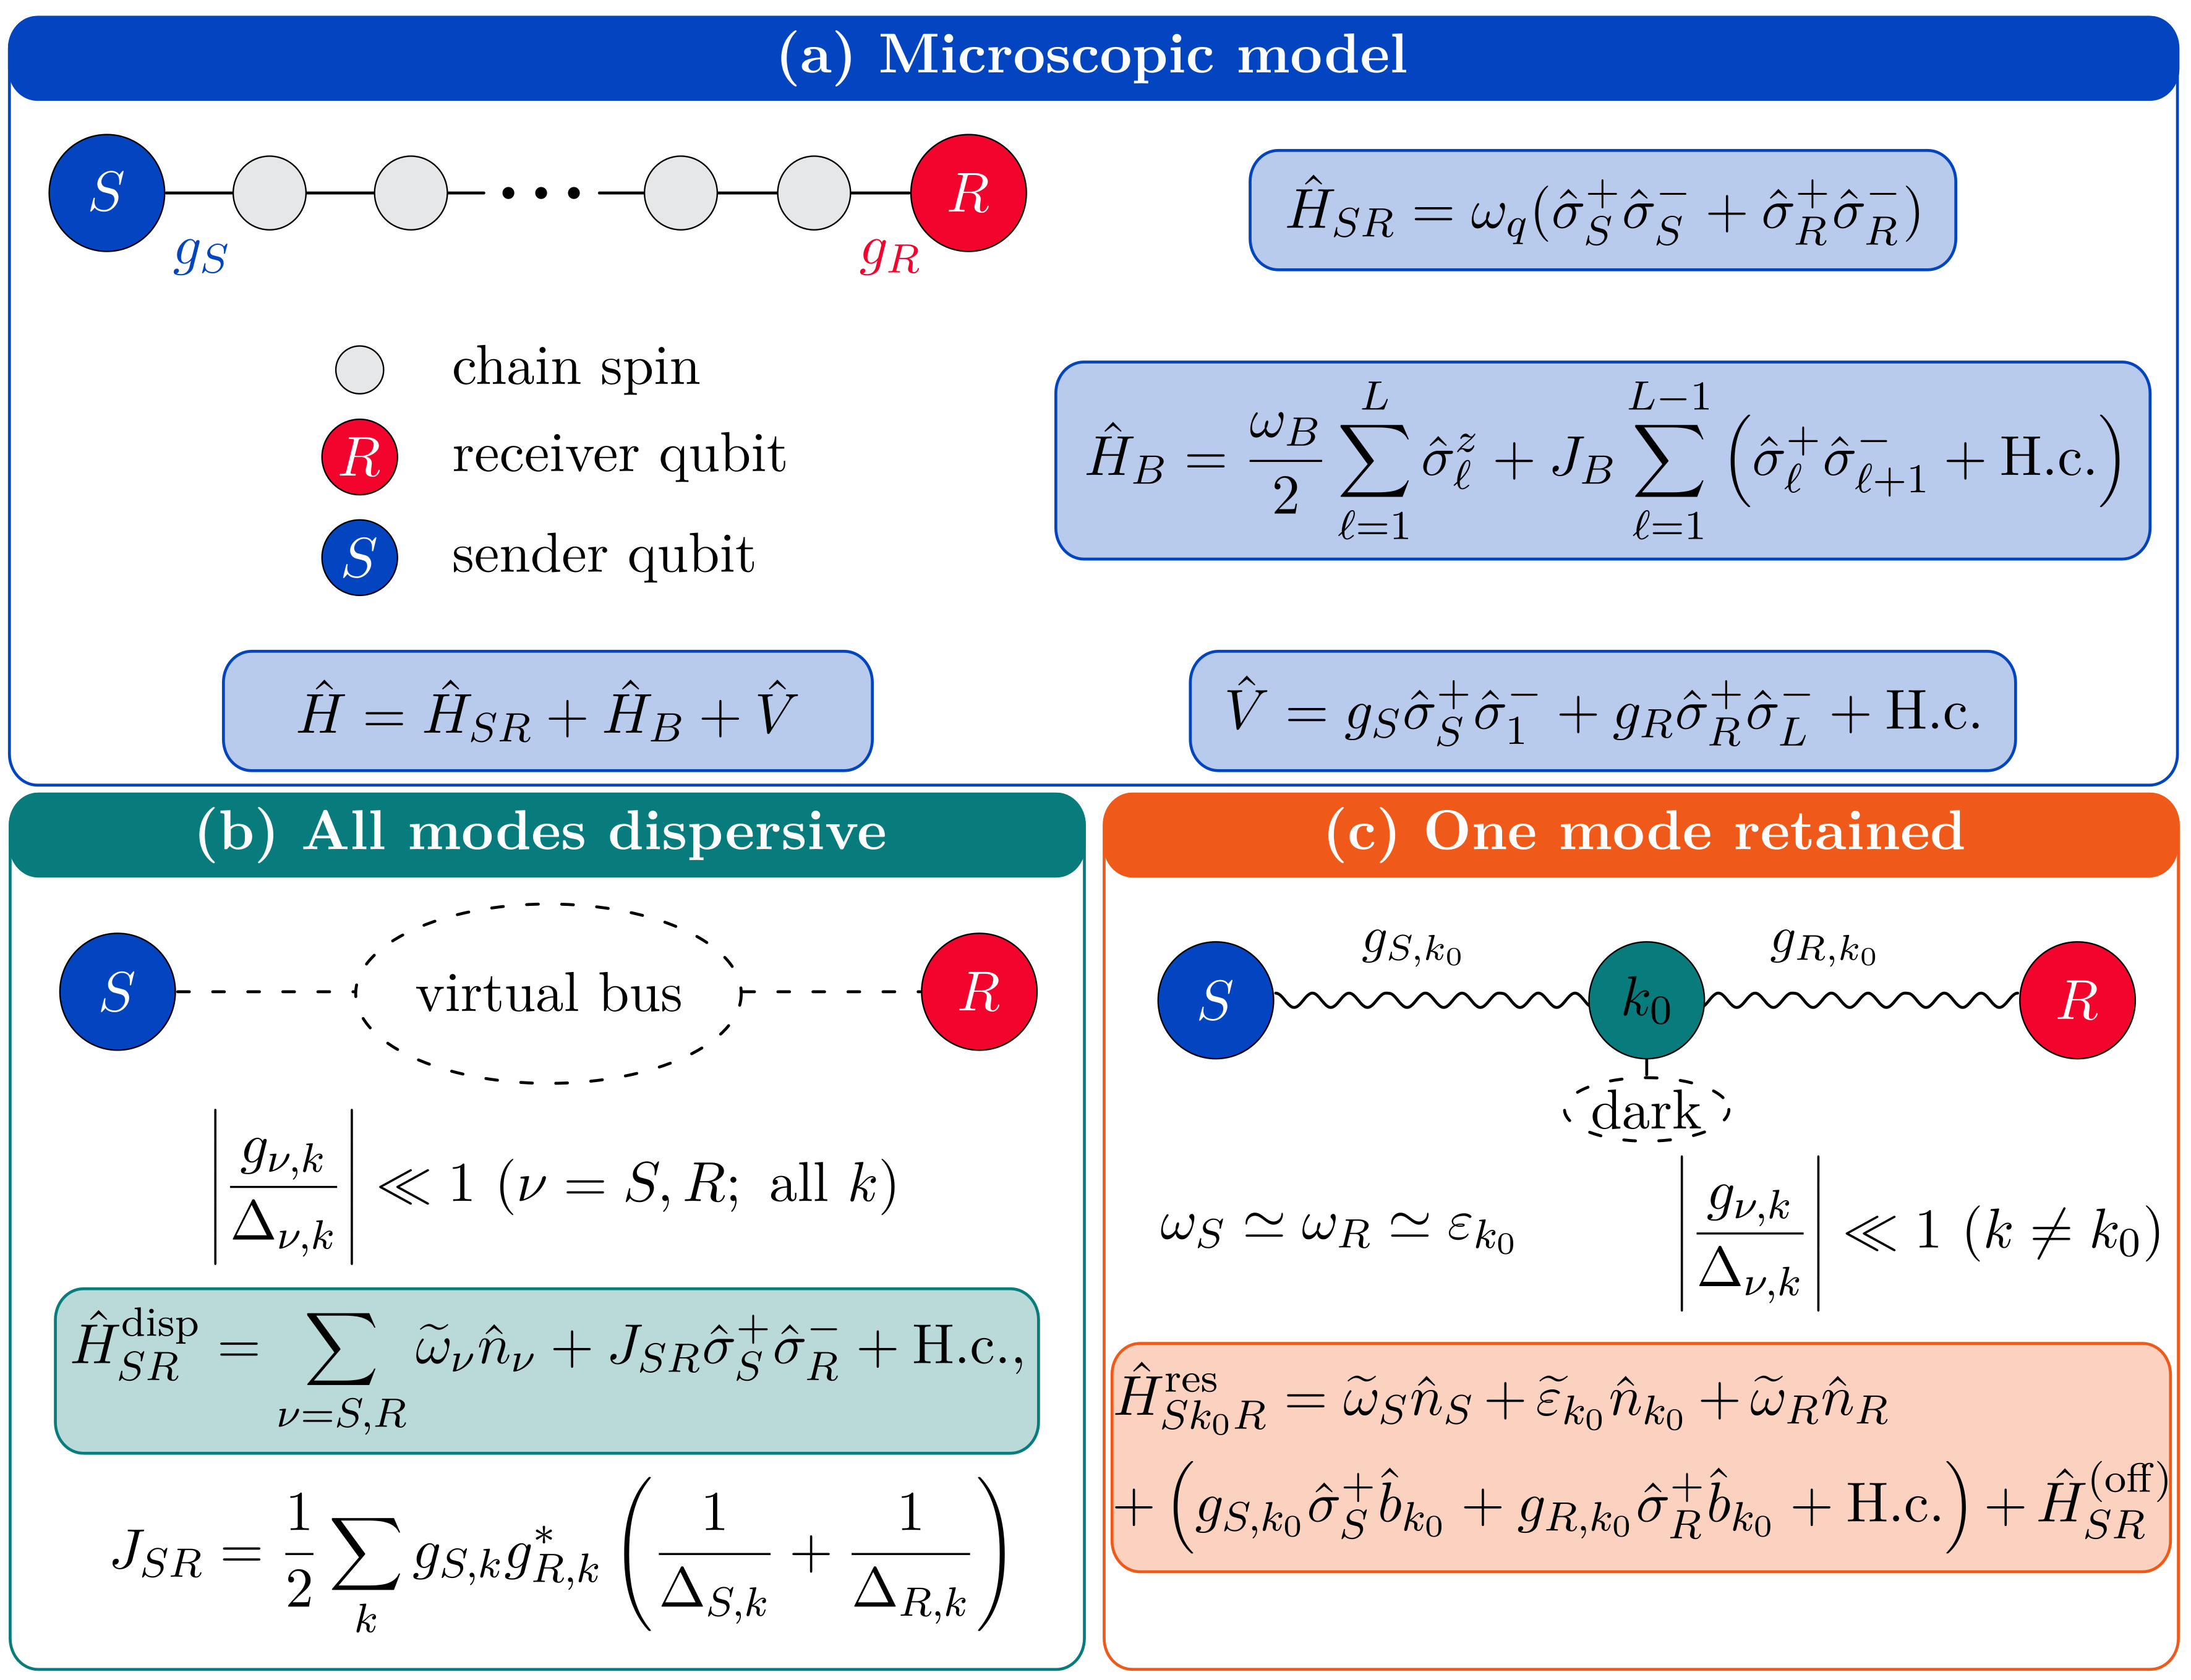

In [2]:
from hashlib import sha256
import shutil
from pathlib import Path
from IPython.display import Image, display

asset_pdf = Path("assets/manuscript/N02_MF1.pdf")
asset_png = Path("assets/manuscript/N02_MF1.png")
target_dir = Path("figures/manuscript")
target_dir.mkdir(parents=True, exist_ok=True)
target_pdf = target_dir / "N02_MF1.pdf"
target_png = target_dir / "N02_MF1.png"
shutil.copy2(asset_pdf, target_pdf)
shutil.copy2(asset_png, target_png)
assert sha256(asset_pdf.read_bytes()).hexdigest() == "5a85de9ac86ef058333f8d7a72a75ffc113e8f12b07274603b77c266a60fa470"
assert sha256(target_pdf.read_bytes()).hexdigest() == "5a85de9ac86ef058333f8d7a72a75ffc113e8f12b07274603b77c266a60fa470"
display(Image(filename=str(target_png), width=920))

**Manuscript Figure N02_MF1. Retained-space choices for a finite quantum bus.**
(a) Sender and receiver qubits couple locally to the endpoints of an open $XX$ chain. (b) If every appreciably coupled mode is dispersive, all bus modes are eliminated and the endpoint exchange is a coherent signed sum over virtual paths. (c) If one isolated mode $k_0$ enters the dynamical window, that mode remains explicit; the bright endpoint state couples to it while the orthogonal combination is dark with respect to that mode. (d) The spectral hierarchy proceeds from all-mode elimination to one retained mode and then a retained mode cluster. An unknown, excited, or thermal bus is a separate preparation/encoding branch rather than another point on that spectral axis.

In [3]:
# QuTiP convention:
# sigmam() = |g><e|, with |e> = basis(2, 0) and |g> = basis(2, 1).
E = basis(2, 0)
G = basis(2, 1)
P_E = E * E.dag()
P_G = G * G.dag()

def local_operator(op, site, nsites):
    factors = [qeye(2) for _ in range(nsites)]
    factors[site] = op
    return tensor(factors)


def spin_operators(L):
    nsites = L + 2
    sm = [local_operator(sigmam(), j, nsites) for j in range(nsites)]
    sp = [op.dag() for op in sm]
    number = [sp[j] * sm[j] for j in range(nsites)]
    return sm, sp, number


def full_spin_model(L, J, omega_b, omega_s, omega_r, g_s, g_r):
    sm, sp, number = spin_operators(L)
    H = omega_s * number[0] + omega_r * number[-1]
    H += omega_b * sum(number[1:-1])
    H += g_s * (sp[0] * sm[1] + sp[1] * sm[0])
    H += g_r * (sp[-1] * sm[-2] + sp[-2] * sm[-1])
    for j in range(1, L):
        H += J * (sp[j] * sm[j + 1] + sp[j + 1] * sm[j])
    return H, sm, sp, number


def product_state(excitations):
    """Tensor product with 1 = excited and 0 = ground."""
    return tensor([E if occupied else G for occupied in excitations])


def one_excitation_site_state(site, nsites):
    excitations = [0] * nsites
    excitations[site] = 1
    return product_state(excitations)


def one_excitation_model(L, J, omega_b, omega_s, omega_r, g_s, g_r):
    D = L + 2
    kets = [basis(D, j) for j in range(D)]
    H = omega_s * kets[0] * kets[0].dag() + omega_r * kets[-1] * kets[-1].dag()
    H += omega_b * sum(kets[j] * kets[j].dag() for j in range(1, L + 1))
    H += g_s * (kets[0] * kets[1].dag() + kets[1] * kets[0].dag())
    H += g_r * (kets[-1] * kets[-2].dag() + kets[-2] * kets[-1].dag())
    for j in range(1, L):
        H += J * (kets[j] * kets[j + 1].dag() + kets[j + 1] * kets[j].dag())
    return H, kets


def bus_modes(L, J, omega_b):
    sites = [basis(L, j) for j in range(L)]
    H = omega_b * qeye(L)
    for j in range(L - 1):
        H += J * (sites[j] * sites[j + 1].dag() + sites[j + 1] * sites[j].dag())
    energies, vectors = H.eigenstates()
    phi = np.column_stack([v.full().ravel() for v in vectors])
    for k in range(L):
        phi[:, k] *= np.exp(-1j * np.angle(phi[0, k]))
    return H, np.asarray(energies), phi


def analytic_modes(L, J, omega_b):
    k = np.arange(1, L + 1)
    ell = np.arange(1, L + 1)[:, None]
    energies = omega_b + 2 * J * np.cos(k * np.pi / (L + 1))
    phi = np.sqrt(2 / (L + 1)) * np.sin(ell * k * np.pi / (L + 1))
    order = np.argsort(energies)
    phi = phi[:, order]
    for j in range(L):
        if phi[0, j] < 0:
            phi[:, j] *= -1
    return energies[order], phi


In [4]:
L_check = 6
J_check = 1.0
omega_b_check = 0.0
H_bus_check, eps_q, phi_q = bus_modes(L_check, J_check, omega_b_check)
eps_a, phi_a = analytic_modes(L_check, J_check, omega_b_check)

parity = np.array([np.sign(np.real(phi_q[-1, k] / phi_q[0, k])) for k in range(L_check)])
parity_expected = np.array([(-1) ** (L_check - 1 - k) for k in range(L_check)])

H_tensor_check, _, _, number_check = full_spin_model(
    L=4, J=1.0, omega_b=0.0, omega_s=0.2, omega_r=0.2, g_s=0.08, g_r=0.08
)
N_total_check = sum(number_check)

algebra = pd.DataFrame({
    "quantity": [
        "spectrum_residual", "mode_orthogonality_residual",
        "endpoint_parity_residual", "excitation_commutator_norm"
    ],
    "value": [
        np.max(np.abs(eps_q - eps_a)),
        np.linalg.norm(phi_q.conj().T @ phi_q - np.eye(L_check)),
        np.max(np.abs(parity - parity_expected)),
        commutator(H_tensor_check, N_total_check).norm(),
    ],
})
save_table(algebra, "N02_D1")
algebra


,quantity,value
0,spectrum_residual,2.220446e-15
1,mode_orthogonality_residual,9.651895e-16
2,endpoint_parity_residual,0.000000e+00
3,excitation_commutator_norm,0.000000e+00


## 4. Operational first method: mode-by-mode small rotation

When every appreciably coupled mode is far detuned, define $\Delta_{\nu k}=\omega_\nu-\varepsilon_k$ for $\nu\in\{S,R\}$ and use

$$
S=\sum_k\left[
\frac{g_{S,k}}{\Delta_{Sk}}|k\rangle\langle S|
+\frac{g_{R,k}}{\Delta_{Rk}}|k\rangle\langle R|
-\mathrm{H.c.}\right].
$$

The endpoint Hamiltonian is

$$
H_{\rm end}=(\omega_S+\delta_S)|S\rangle\langle S|
+(\omega_R+\delta_R)|R\rangle\langle R|
+J_{SR}|S\rangle\langle R|+\mathrm{H.c.},
$$

$$
\delta_\nu=\sum_k\frac{|g_{\nu,k}|^2}{\Delta_{\nu k}},
\qquad
J_{SR}=\frac12\sum_k g_{S,k}g_{R,k}^*
\left(\frac1{\Delta_{Sk}}+\frac1{\Delta_{Rk}}\right).
$$

The physical resonance is $\omega_S+\delta_S=\omega_R+\delta_R$. The exchange is a signed coherent sum: a small value may reflect controlled destructive interference, but it may also hide terms that individually violate the dispersive condition.


In [5]:
def endpoint_effective(L, J, omega_b, omega_s, omega_r, g_s, g_r):
    _, energies, phi = bus_modes(L, J, omega_b)
    g_sk = g_s * phi[0, :]
    g_rk = g_r * phi[-1, :]
    delta_s_k = omega_s - energies
    delta_r_k = omega_r - energies
    delta_s = np.sum(np.abs(g_sk) ** 2 / delta_s_k)
    delta_r = np.sum(np.abs(g_rk) ** 2 / delta_r_k)
    J_sr = 0.5 * np.sum(
        g_sk * np.conj(g_rk) * (1 / delta_s_k + 1 / delta_r_k)
    )
    H = Qobj(
        [[omega_s + delta_s, J_sr], [np.conj(J_sr), omega_r + delta_r]],
        dims=[[2], [2]],
    )
    data = {
        "energies": energies,
        "phi": phi,
        "g_sk": g_sk,
        "g_rk": g_rk,
        "delta_s_k": delta_s_k,
        "delta_r_k": delta_r_k,
        "delta_s": delta_s,
        "delta_r": delta_r,
        "J_sr": J_sr,
    }
    return H, data


def selected_mode_effective(L, J, omega_b, omega_s, omega_r, g_s, g_r, k0):
    _, energies, phi = bus_modes(L, J, omega_b)
    g_sk = g_s * phi[0, :]
    g_rk = g_r * phi[-1, :]
    mask = np.arange(L) != k0
    ds = omega_s - energies[mask]
    dr = omega_r - energies[mask]
    shift_s = np.sum(np.abs(g_sk[mask]) ** 2 / ds)
    shift_r = np.sum(np.abs(g_rk[mask]) ** 2 / dr)
    J_off = 0.5 * np.sum(g_sk[mask] * np.conj(g_rk[mask]) * (1 / ds + 1 / dr))
    H = Qobj([
        [omega_s + shift_s, g_sk[k0], J_off],
        [np.conj(g_sk[k0]), energies[k0], np.conj(g_rk[k0])],
        [np.conj(J_off), g_rk[k0], omega_r + shift_r],
    ], dims=[[3], [3]])
    return H, {
        "energies": energies, "phi": phi, "g_sk": g_sk, "g_rk": g_rk,
        "J_off": J_off, "shift_s": shift_s, "shift_r": shift_r,
    }


def endpoint_two_qubit_ket(psi_end):
    c_s, c_r = psi_end.full().ravel()
    return c_s * tensor(E, G) + c_r * tensor(G, E)


def endpoint_metrics_from_tensor(states, L, n_receiver, n_bus):
    rho_sr = [ket2dm(state).ptrace([0, L + 1]) for state in states]
    C = np.array([concurrence(rho) for rho in rho_sr])
    P_R = np.asarray(expect(n_receiver, states), dtype=float)
    P_bus = np.asarray(expect(n_bus, states), dtype=float)
    return rho_sr, C, P_R, P_bus


## 5. Projection, boundary resolvent, and selected-mode repair

Projection onto the endpoints gives the energy-dependent boundary self-energy

$$
\Sigma(E)=W^\dagger(E-H_B)^{-1}W,
$$

where $W$ couples the endpoints to bus sites $1$ and $L$. The off-diagonal entry is the boundary Green function

$$
\Sigma_{SR}(E)=g_Sg_R^*\langle L|(E-H_B)^{-1}|1\rangle.
$$

Expanding the resolvent around the endpoint energies reproduces the small-rotation Hamiltonian. The unexpanded resolvent provides the failure diagnosis: if a pole enters the dynamical window, the corresponding mode is not fast.

For one isolated pole $k_0$, enlarge the slow space to

$$
\mathcal P_{\rm slow}=\mathrm{span}\{|S\rangle,|k_0\rangle,|R\rangle\}
$$

and eliminate only the remaining modes. If several poles overlap, retain the mode cluster rather than adding higher-order corrections to an endpoint-only model whose retained space is wrong.


## 6. Dispersive benchmark and physical-frame reconstruction

The first benchmark uses an even chain, so the endpoint frequency can lie between two bus modes without coinciding with a band-centre pole. The exact tensor-product spin dynamics are compared with the endpoint model in the same endpoint representation.

The small rotation also reconstructs the eliminated bus amplitudes,

$$
c_k(t)\simeq-\frac{g_{S,k}}{\Delta_{S,k}}c_S(t)
-\frac{g_{R,k}}{\Delta_{R,k}}c_R(t),
\qquad
c_\ell(t)=\sum_k\phi_k(\ell)c_k(t).
$$

Elimination removes the bus as an independent slow coordinate; it does not set the physical virtual wavefunction to zero. The reconstruction therefore provides a direct test of the physical frame in which bus occupation and spatial profile are measured.

In [6]:
L = 4
J = 1.0
omega_b = 0.0
omega_s = omega_r = 0.0
g_s = g_r = 0.08

H_full, sm_full, sp_full, n_full = full_spin_model(
    L, J, omega_b, omega_s, omega_r, g_s, g_r
)
H_end, disp = endpoint_effective(L, J, omega_b, omega_s, omega_r, g_s, g_r)

psi_full = one_excitation_site_state(0, L + 2)
psi_end = basis(2, 0)
J_sr = abs(disp["J_sr"])
t_transfer = np.pi / (2 * J_sr)
tlist = np.linspace(0, 1.2 * t_transfer, 500)

result_full = sesolve(H_full, psi_full, tlist, options=SOLVER)
result_end = sesolve(H_end, psi_end, tlist, options=SOLVER)

n_receiver = n_full[-1]
n_bus = sum(n_full[1:-1])
rho_sr_full, C_full, P_R_full, P_bus_full = endpoint_metrics_from_tensor(
    result_full.states, L, n_receiver, n_bus
)

rho_sr_end = [ket2dm(endpoint_two_qubit_ket(state)) for state in result_end.states]
C_end = np.array([concurrence(rho) for rho in rho_sr_end])
P_R_end = np.array([expect(tensor(qeye(2), P_E), rho) for rho in rho_sr_end])
D_end = np.array([tracedist(rho_a, rho_b) for rho_a, rho_b in zip(rho_sr_full, rho_sr_end)])

eta_max = max(
    np.max(np.abs(disp["g_sk"] / disp["delta_s_k"])),
    np.max(np.abs(disp["g_rk"] / disp["delta_r_k"])),
)
cumulative_dressing = max(
    np.sum(np.abs(disp["g_sk"] / disp["delta_s_k"]) ** 2),
    np.sum(np.abs(disp["g_rk"] / disp["delta_r_k"]) ** 2),
)

site_kets = [one_excitation_site_state(j, L + 2) for j in range(L + 2)]
idx_profile = int(np.argmax(C_full))
state_profile = result_full.states[idx_profile]
c_s = site_kets[0].overlap(state_profile)
c_r = site_kets[-1].overlap(state_profile)
c_k = -(disp["g_sk"] / disp["delta_s_k"]) * c_s - (disp["g_rk"] / disp["delta_r_k"]) * c_r
profile_reconstructed = disp["phi"] @ c_k
profile_exact = np.array([site_kets[j].overlap(state_profile) for j in range(1, L + 1)])
profile_rmse = np.sqrt(np.mean(np.abs(profile_exact - profile_reconstructed) ** 2))

summary_disp = pd.DataFrame({
    "quantity": [
        "abs_J_SR", "eta_max", "cumulative_dressing", "max_concurrence_exact",
        "max_receiver_population_exact", "max_bus_population",
        "max_endpoint_trace_distance", "profile_rmse"
    ],
    "value": [
        J_sr, eta_max, cumulative_dressing, C_full.max(), P_R_full.max(),
        P_bus_full.max(), D_end.max(), profile_rmse
    ],
})
save_table(summary_disp, "N02_D2")
summary_disp


,quantity,value
0,abs_J_SR,0.006400
1,eta_max,0.077860
2,cumulative_dressing,0.012800
3,max_concurrence_exact,0.997136
4,max_receiver_population_exact,0.998993
5,max_bus_population,0.048951
6,max_endpoint_trace_distance,0.059325
7,profile_rmse,0.059865


The phase-corrected average qubit-transfer fidelity for a vacuum bus is

$$
\overline F(t)=\frac12+\frac{|f(t)|}{3}+\frac{|f(t)|^2}{6},
$$

where $f(t)$ is the sender-to-receiver amplitude after correcting its known phase. This quantity tests more than population transfer: it is sensitive to the coherent amplitude required to transmit an arbitrary qubit.


In [7]:
f_exact = np.array([site_kets[-1].overlap(state) for state in result_full.states])
f_effective = np.array([state.full().ravel()[1] for state in result_end.states])
F_exact = 0.5 + np.abs(f_exact) / 3 + np.abs(f_exact) ** 2 / 6
F_effective = 0.5 + np.abs(f_effective) / 3 + np.abs(f_effective) ** 2 / 6

profile_table = pd.DataFrame({
    "site": np.arange(1, L + 1),
    "exact_real": profile_exact.real,
    "exact_imag": profile_exact.imag,
    "reconstructed_real": profile_reconstructed.real,
    "reconstructed_imag": profile_reconstructed.imag,
})
save_table(profile_table, "N02_D3")


## 7. Near resonance: endpoint-only failure and selected-mode recovery

For an odd chain, one mode lies at the band centre. Placing the endpoints close to that mode deliberately violates all-mode elimination. The endpoint-only Hamiltonian remains mathematically well defined away from the exact pole, but it is the wrong retained model. The selected-mode Hamiltonian restores the real mediator occupation and its associated memory.

After the other modes are eliminated, the relevant resonance is dressed:
$\omega_S+\delta_S^{(\mathrm{off})}\simeq\varepsilon_{k_0}
\simeq\omega_R+\delta_R^{(\mathrm{off})}$.
For generally complex endpoint couplings, define

$$
G_{k_0}=\sqrt{|g_{S,k_0}|^2+|g_{R,k_0}|^2},
$$

$$
|B\rangle=
\frac{g_{S,k_0}|S\rangle+g_{R,k_0}|R\rangle}{G_{k_0}},
\qquad
|D\rangle=
\frac{g_{R,k_0}^{*}|S\rangle-g_{S,k_0}^{*}|R\rangle}{G_{k_0}}.
$$

With the Hamiltonian convention used above,
$\langle k_0|H|B\rangle=G_{k_0}$ and
$\langle k_0|H|D\rangle=0$.
Thus only the bright state couples directly to the selected mode.
The dark state is dark only with respect to that vertex: unequal dressed
endpoint energies, the off-resonant endpoint interaction, omitted modes,
or additional noise can still mix or decay it.

In [8]:
L_res = 5
omega_res = 0.06
g_res = 0.08
H_full_res, kets_res = one_excitation_model(
    L_res, J, omega_b, omega_res, omega_res, g_res, g_res
)
H_end_res, data_res = endpoint_effective(
    L_res, J, omega_b, omega_res, omega_res, g_res, g_res
)
k0 = int(np.argmin(np.abs(data_res["energies"] - omega_res)))
H_sel_res, selected = selected_mode_effective(
    L_res, J, omega_b, omega_res, omega_res, g_res, g_res, k0
)

t_res = np.linspace(0, 120, 600)
res_full = sesolve(H_full_res, basis(L_res + 2, 0), t_res, options=SOLVER)
res_end = sesolve(H_end_res, basis(2, 0), t_res, options=SOLVER)
res_sel = sesolve(H_sel_res, basis(3, 0), t_res, options=SOLVER)

amp_full_s = np.array([kets_res[0].overlap(state) for state in res_full.states])
amp_full_r = np.array([kets_res[-1].overlap(state) for state in res_full.states])
C_full_res = 2 * np.abs(amp_full_s * np.conj(amp_full_r))
P_R_full_res = np.abs(amp_full_r) ** 2

amp_end = np.array([state.full().ravel() for state in res_end.states])
amp_sel = np.array([state.full().ravel() for state in res_sel.states])
C_end_res = 2 * np.abs(amp_end[:, 0] * np.conj(amp_end[:, 1]))
C_sel_res = 2 * np.abs(amp_sel[:, 0] * np.conj(amp_sel[:, 2]))
P_R_end_res = np.abs(amp_end[:, 1]) ** 2
P_R_sel_res = np.abs(amp_sel[:, 2]) ** 2
P_mode_sel_res = np.abs(amp_sel[:, 1]) ** 2

rmse_endpoint = np.sqrt(np.mean((C_full_res - C_end_res) ** 2))
rmse_selected = np.sqrt(np.mean((C_full_res - C_sel_res) ** 2))
delta_iso = np.min(np.abs(np.delete(data_res["energies"], k0) - data_res["energies"][k0]))

summary_res = pd.DataFrame({
    "quantity": [
        "selected_mode_index", "selected_mode_energy", "spectral_isolation",
        "max_concurrence_exact", "max_concurrence_endpoint_only",
        "max_concurrence_selected_mode", "selected_mode_peak_population",
        "concurrence_rmse_endpoint_only", "concurrence_rmse_selected_mode"
    ],
    "value": [
        k0 + 1, data_res["energies"][k0], delta_iso,
        C_full_res.max(), C_end_res.max(), C_sel_res.max(), P_mode_sel_res.max(),
        rmse_endpoint, rmse_selected
    ],
})
save_table(summary_res, "N02_D4")
summary_res


,quantity,value
0,selected_mode_index,3.000000e+00
1,selected_mode_energy,8.881784e-16
2,spectral_isolation,1.000000e+00
3,max_concurrence_exact,9.515455e-01
4,max_concurrence_endpoint_only,9.999958e-01
5,max_concurrence_selected_mode,9.623292e-01
6,selected_mode_peak_population,4.130048e-01
7,concurrence_rmse_endpoint_only,4.194239e-01
8,concurrence_rmse_selected_mode,6.961521e-03


## 8. Notebook diagnostic: spectrum, reconstruction, and retained-space repair

The figure combines the spectral structure, the controlled dispersive regime, physical-frame reconstruction, and the structural failure of all-mode elimination near a pole.


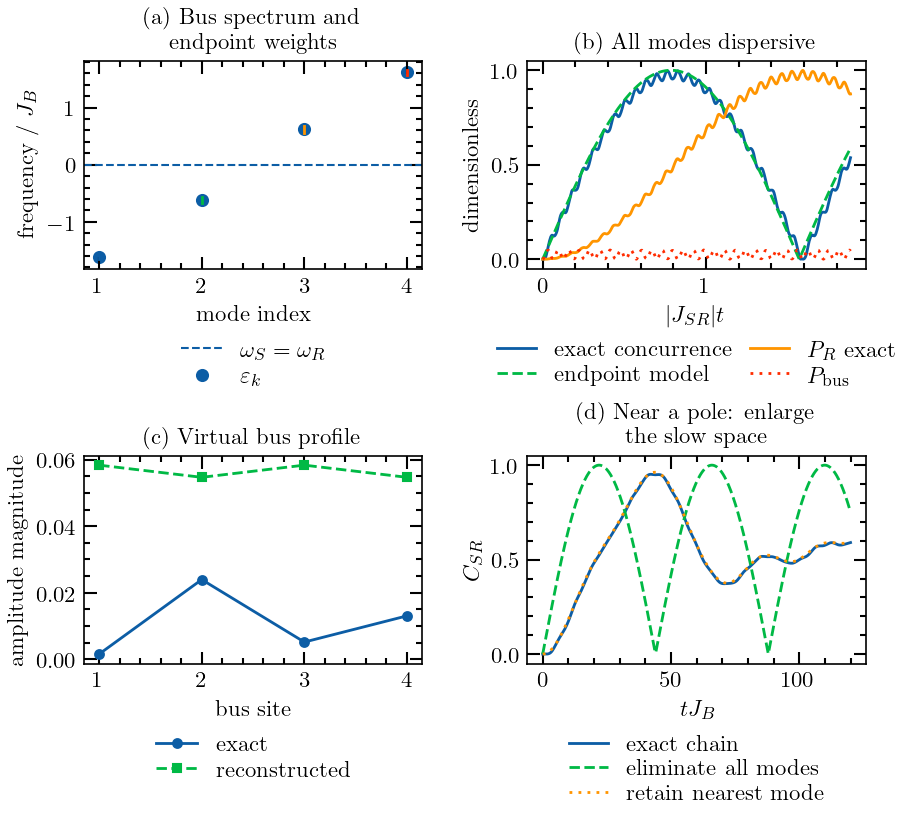

In [9]:
fig = plt.figure(figsize=(FIG_WIDTH_150MM, 4.90))
gs = fig.add_gridspec(
    2, 2,
    left=0.105, right=0.988, bottom=0.105, top=0.925,
    hspace=0.9, wspace=0.31,
)
axes = np.array([
    [fig.add_subplot(gs[0, 0]), fig.add_subplot(gs[0, 1])],
    [fig.add_subplot(gs[1, 0]), fig.add_subplot(gs[1, 1])],
])

ax = axes[0, 0]
mode_index = np.arange(1, 5)
ax.axhline(omega_s, lw=1.0, ls="--", label=r"$\omega_S=\omega_R$")
ax.scatter(mode_index, disp["energies"], s=28, label=r"$\varepsilon_k$")
for k, (e, left, right) in enumerate(
    zip(disp["energies"], np.abs(disp["phi"][0]), np.abs(disp["phi"][-1])),
    start=1
):
    ax.plot([k, k], [e - 0.10 * left, e + 0.10 * right], lw=1.35)
ax.set(
    xlabel="mode index",
    ylabel=r"frequency / $J_B$",
    title="(a) Bus spectrum and\nendpoint weights"
)
ax.legend(
    loc="upper center",
    bbox_to_anchor=(0.5, -0.30),
    frameon=False,
    handlelength=1.8,
    labelspacing=0.20,
    borderaxespad=0.0,
)

ax = axes[0, 1]
scaled = J_sr * tlist
ax.plot(scaled, C_full, label="exact concurrence")
ax.plot(scaled, C_end, "--", label="endpoint model")
ax.plot(scaled, P_R_full, label=r"$P_R$ exact")
ax.plot(scaled, P_bus_full, linestyle=(0, (1.0, 2.2)), label=r"$P_{\rm bus}$")
ax.set(
    xlabel=r"$|J_{SR}|t$",
    ylabel="dimensionless",
    title="(b) All modes dispersive"
)
ax.legend(
    loc="upper center",
    bbox_to_anchor=(0.5, -0.30),
    ncol=2,
    frameon=False,
    handlelength=1.7,
    columnspacing=0.8,
    labelspacing=0.20,
    borderaxespad=0.0,
)

ax = axes[1, 0]
sites = np.arange(1, L + 1)
ax.plot(sites, np.abs(profile_exact), "o-", label="exact")
ax.plot(sites, np.abs(profile_reconstructed), "s--", label="reconstructed")
ax.set(
    xlabel="bus site",
    ylabel="amplitude magnitude",
    title="(c) Virtual bus profile"
)
ax.set_xticks(sites)
ax.legend(
    loc="upper center",
    bbox_to_anchor=(0.5, -0.30),
    frameon=False,
    handlelength=1.8,
    labelspacing=0.20,
    borderaxespad=0.0,
)

ax = axes[1, 1]
ax.plot(t_res, C_full_res, label="exact chain")
ax.plot(t_res, C_end_res, "--", label="eliminate all modes")
ax.plot(t_res, C_sel_res, linestyle=(0, (1.0, 2.2)), label="retain nearest mode")
ax.set(
    xlabel=r"$tJ_B$",
    ylabel=r"$C_{SR}$",
    title="(d) Near a pole: enlarge\nthe slow space"
)
ax.legend(
    loc="upper center",
    bbox_to_anchor=(0.5, -0.30),
    frameon=False,
    handlelength=1.7,
    labelspacing=0.18,
    borderaxespad=0.0,
)

save_figure(fig, "N02_F1")
plt.show()
plt.close(fig)


**Notebook Figure N02_F1. Spectrum, virtual reconstruction, and retained-space repair.**
(a) The open-chain spectrum and endpoint weights determine the virtual paths and their alternating signs. (b) In the dispersive regime, the endpoint Hamiltonian reproduces remote concurrence and transfer while the bus remains weakly occupied. (c) The eliminated bus retains a reconstructible virtual spatial profile. (d) Near an isolated pole, the endpoint-only model fails and the selected-mode model restores the entanglement dynamics.

## 9. Lossy buses: coherent self-energy and induced decay

For a bus with amplitude-loss matrix $K$, the retarded boundary self-energy is

$$
\Sigma(E)=W^\dagger\left[E-H_B+\frac{i}{2}K\right]^{-1}W.
$$

Its Hermitian part gives endpoint shifts and coherent exchange,

$$
\Delta H(E)=\frac{\Sigma(E)+\Sigma^\dagger(E)}{2},
$$

while

$$
\Gamma(E)=i\left[\Sigma(E)-\Sigma^\dagger(E)\right]
$$

is the induced endpoint decay matrix. For passive amplitude loss, $\Gamma(E)$ is positive semidefinite. Diagonalizing it gives the collective decay channels; independent local endpoint rates require additional symmetry or secular assumptions.

A useful response ratio is

$$
\mathcal R_{\rm bus}(E)=
\frac{\lambda_{\max}[\Gamma(E)]}{2|\Delta H_{SR}(E)|},
$$

which compares the largest induced decay scale with the coherent boundary exchange generated by the same response. It is a diagnostic for this reduction, not a protocol-independent cooperativity. The selected-mode protocol instead retains the lossy mode and its real occupation explicitly.

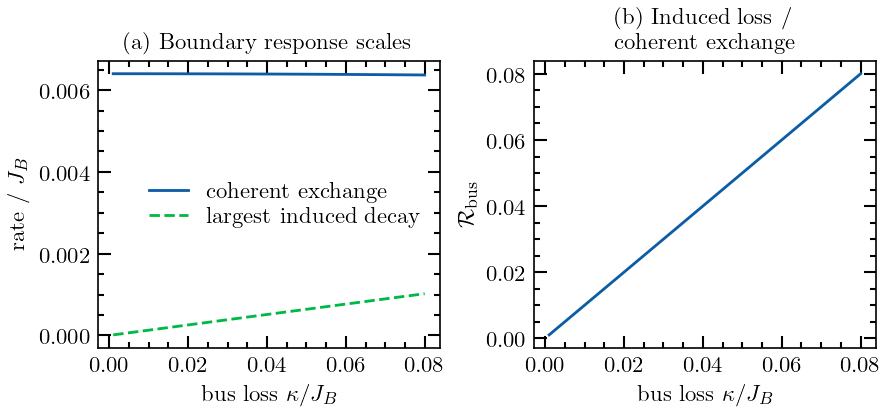

In [10]:
def complex_self_energy(L, J, omega_b, g_s, g_r, energy, kappa):
    H_bus, _, _ = bus_modes(L, J, omega_b)
    site_1 = basis(L, 0)
    site_L = basis(L, L - 1)
    W = Qobj(np.column_stack([
        (g_s * site_1).full().ravel(),
        (g_r * site_L).full().ravel(),
    ]), dims=[[L], [2]])
    K = kappa * qeye(L)
    resolvent = (energy * qeye(L) - H_bus + 0.5j * K).inv()
    Sigma = W.dag() * resolvent * W
    DeltaH = 0.5 * (Sigma + Sigma.dag())
    Gamma = 1j * (Sigma - Sigma.dag())
    return Sigma, DeltaH, Gamma


kappa_grid = np.linspace(0.001, 0.08, 50)
response_rows = []
for kappa in kappa_grid:
    Sigma, DeltaH, Gamma = complex_self_energy(
        L=4, J=1.0, omega_b=0.0, g_s=0.08, g_r=0.08,
        energy=0.0, kappa=kappa,
    )
    gamma_eigs = np.real(Gamma.eigenenergies())
    gamma_max = np.max(gamma_eigs)
    gamma_min = np.min(gamma_eigs)
    exchange = abs(DeltaH.full()[0, 1])
    ratio = gamma_max / (2 * exchange)
    response_rows.append((kappa, exchange, gamma_max, gamma_min, ratio))

response = pd.DataFrame(response_rows, columns=[
    "kappa", "coherent_exchange", "largest_induced_decay",
    "smallest_decay_eigenvalue", "R_bus",
])
save_table(response, "N02_D7")

fig, axes = plt.subplots(
    1, 2, figsize=(FIG_WIDTH_150MM, 2.75), constrained_layout=True
)
axes[0].plot(response["kappa"], response["coherent_exchange"], label="coherent exchange")
axes[0].plot(response["kappa"], response["largest_induced_decay"], "--", label="largest induced decay")
axes[0].set(
    xlabel=r"bus loss $\kappa/J_B$",
    ylabel=r"rate / $J_B$",
    title="(a) Boundary response scales",
)
axes[0].legend(frameon=False, handlelength=1.7, labelspacing=0.20)

axes[1].plot(response["kappa"], response["R_bus"])
axes[1].set(
    xlabel=r"bus loss $\kappa/J_B$",
    ylabel=r"$\mathcal{R}_{\rm bus}$",
    title="(b) Induced loss /\ncoherent exchange",
)

save_figure(fig, "N02_F2")
plt.show()
plt.close(fig)

**Notebook Figure N02_F2. Complex boundary response of a lossy dispersive bus.** The coherent exchange and induced endpoint decay are obtained from the same retarded self-energy. The ratio $\mathcal R_{\rm bus}$ compares the dominant induced decay with the coherent boundary exchange and is interpreted together with the full frequency dependence of the response.

### 9.1 Protocol-dependent loss exposure

The boundary self-energy identifies induced endpoint loss, but comparing transfer protocols requires a channel metric. The following QuTiP calculation evolves the six cardinal qubit states with `mesolve`, traces out sender and bus, removes the known transfer phase, and averages the receiver-state fidelity. These six states form a qubit two-design, so the discrete average equals the Bloch-sphere average for this channel fidelity.

The two parameter sets are chosen to represent the two controlled limits rather than to optimize one protocol against the other: an off-resonant, weakly populated dispersive bus and a dressed-resonant selected-mode bus. A small endpoint damping rate penalizes the slower dispersive protocol, whereas increasing bus loss penalizes real selected-mode occupation. The scan is wide enough to display both sides of this competition.

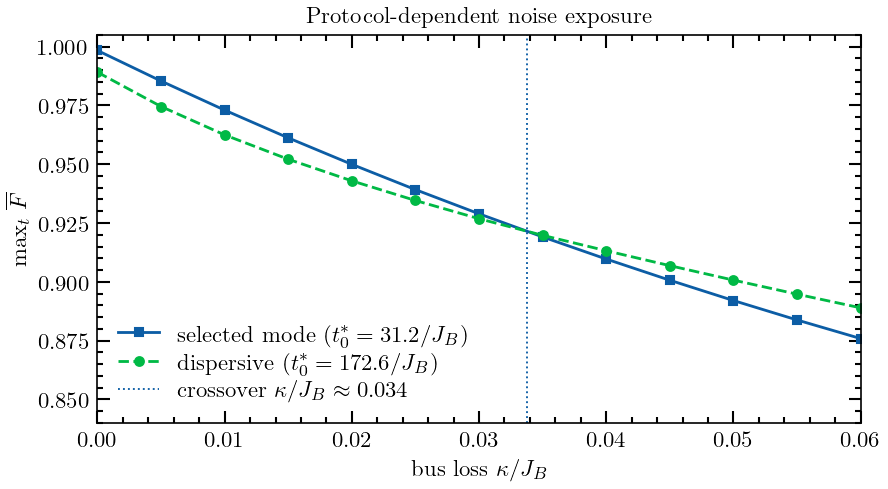

,quantity,value
0,dispersive_closed_transfer_time,172.625139
1,selected_mode_closed_transfer_time,31.201335
2,dispersive_closed_max_receiver_population,0.999412
3,selected_mode_closed_max_receiver_population,0.999611
4,dispersive_closed_max_bus_population,0.114649
5,selected_mode_closed_max_bus_population,0.509801
6,dispersive_integrated_bus_exposure,9.932606
7,selected_mode_integrated_bus_exposure,8.007741
8,estimated_crossover_kappa,0.033764


In [11]:
def closed_transfer_time(L, omega, g, t_guess, max_extensions=5):
    """Find an interior closed-system receiver-population maximum."""
    H, sm, sp, number = full_spin_model(L, 1.0, 0.0, omega, omega, g, g)
    psi_one = one_excitation_site_state(0, L + 2)
    n_bus_local = sum(number[1:-1])
    horizon = float(t_guess)
    for _ in range(max_extensions):
        t_probe = np.linspace(0.0, horizon, 900)
        result = sesolve(
            H, psi_one, t_probe,
            e_ops=[number[-1], n_bus_local],
            options=SOLVER,
        )
        receiver = np.asarray(result.expect[0], dtype=float)
        bus_population = np.asarray(result.expect[1], dtype=float)
        idx = int(np.argmax(receiver))
        if 2 <= idx <= len(t_probe) - 3:
            exposure = np.trapezoid(bus_population[: idx + 1], t_probe[: idx + 1])
            return (
                H, sm, number,
                float(t_probe[idx]), float(receiver[idx]),
                float(bus_population[: idx + 1].max()), float(exposure),
            )
        horizon *= 1.5
    raise RuntimeError("Transfer maximum remained on the scan boundary; extend the search window.")


def six_state_average_fidelity_curve(H, sm, L, tlist, kappa, gamma_end):
    logical_zero = G
    logical_one = E
    inputs = [
        logical_zero,
        logical_one,
        (logical_zero + logical_one).unit(),
        (logical_zero - logical_one).unit(),
        (logical_zero + 1j * logical_one).unit(),
        (logical_zero - 1j * logical_one).unit(),
    ]

    c_ops = [np.sqrt(gamma_end) * sm[0], np.sqrt(gamma_end) * sm[-1]]
    c_ops += [np.sqrt(kappa) * sm[j] for j in range(1, L + 1)]

    receiver_states = []
    for psi_in in inputs:
        psi0 = tensor([psi_in] + [G for _ in range(L + 1)])
        result = mesolve(H, ket2dm(psi0), tlist, c_ops=c_ops, options=SOLVER)
        receiver_states.append([state.ptrace(L + 1) for state in result.states])

    F_curve = np.empty(len(tlist))
    plus_trajectory = receiver_states[2]
    for n in range(len(tlist)):
        coherence = plus_trajectory[n][0, 1]
        correction_phase = np.angle(coherence) if abs(coherence) > 1e-14 else 0.0
        phase_correction = np.exp(-1j * correction_phase) * P_E + P_G
        values = []
        for psi_in, trajectory in zip(inputs, receiver_states):
            rho_corrected = phase_correction * trajectory[n] * phase_correction.dag()
            values.append(fidelity(rho_corrected, psi_in) ** 2)
        F_curve[n] = np.mean(values)
    return F_curve


L_loss = 3
gamma_end = 2.0e-4

# Dispersive protocol: off-resonant endpoints, weak real bus occupation.
(
    H_disp_loss, sm_disp_loss, _, t_disp_loss, Pmax_disp_closed,
    Pbusmax_disp_closed, Abus_disp_closed,
) = closed_transfer_time(L_loss, omega=2.0, g=0.20, t_guess=210)

# Selected-mode protocol: endpoints are resonant with the isolated band-centre mode.
(
    H_res_loss, sm_res_loss, _, t_res_loss, Pmax_res_closed,
    Pbusmax_res_closed, Abus_res_closed,
) = closed_transfer_time(L_loss, omega=0.0, g=0.10, t_guess=50)

t_disp_grid = np.linspace(0.0, 1.20 * t_disp_loss, 121)
t_res_grid_loss = np.linspace(0.0, 1.35 * t_res_loss, 121)
kappa_values = np.linspace(0.0, 0.060, 13)

F_disp_curves = [
    six_state_average_fidelity_curve(H_disp_loss, sm_disp_loss, L_loss, t_disp_grid, kappa, gamma_end)
    for kappa in kappa_values
]
F_res_curves = [
    six_state_average_fidelity_curve(H_res_loss, sm_res_loss, L_loss, t_res_grid_loss, kappa, gamma_end)
    for kappa in kappa_values
]

F_disp_loss = np.array([curve.max() for curve in F_disp_curves])
F_res_loss = np.array([curve.max() for curve in F_res_curves])
t_opt_disp = np.array([t_disp_grid[np.argmax(curve)] for curve in F_disp_curves])
t_opt_res = np.array([t_res_grid_loss[np.argmax(curve)] for curve in F_res_curves])

difference = F_disp_loss - F_res_loss
crossing_idx = np.where(difference[:-1] * difference[1:] <= 0)[0]
if len(crossing_idx):
    i = int(crossing_idx[0])
    x0, x1 = kappa_values[i], kappa_values[i + 1]
    y0, y1 = difference[i], difference[i + 1]
    kappa_cross = float(x0 - y0 * (x1 - x0) / (y1 - y0))
else:
    kappa_cross = np.nan

loss_protocols = pd.DataFrame({
    "kappa": kappa_values,
    "Fmax_dispersive": F_disp_loss,
    "Fmax_selected_mode": F_res_loss,
    "topt_dispersive": t_opt_disp,
    "topt_selected_mode": t_opt_res,
})
save_table(loss_protocols, "N02_D8")

fig, ax = plt.subplots(
    figsize=(FIG_WIDTH_150MM, 3.25), constrained_layout=True
)
ax.plot(kappa_values, F_res_loss, "s-", label=fr"selected mode ($t_0^*={t_res_loss:.1f}/J_B$)")
ax.plot(kappa_values, F_disp_loss, "o--", label=fr"dispersive ($t_0^*={t_disp_loss:.1f}/J_B$)")
if np.isfinite(kappa_cross):
    ax.axvline(kappa_cross, lw=0.9, ls=":", label=fr"crossover $\kappa/J_B\approx{kappa_cross:.3f}$")
ax.set(
    xlabel=r"bus loss $\kappa/J_B$",
    ylabel=r"$\max_t\,\overline{F}$",
    title="Protocol-dependent noise exposure",
    xlim=(0.0, 0.060),
    ylim=(0.84, 1.005),
)
ax.legend(frameon=False, handlelength=1.8, labelspacing=0.22)
save_figure(fig, "N02_F3")
plt.show()
plt.close(fig)

loss_summary = pd.DataFrame({
    "quantity": [
        "dispersive_closed_transfer_time",
        "selected_mode_closed_transfer_time",
        "dispersive_closed_max_receiver_population",
        "selected_mode_closed_max_receiver_population",
        "dispersive_closed_max_bus_population",
        "selected_mode_closed_max_bus_population",
        "dispersive_integrated_bus_exposure",
        "selected_mode_integrated_bus_exposure",
        "estimated_crossover_kappa",
    ],
    "value": [
        t_disp_loss,
        t_res_loss,
        Pmax_disp_closed,
        Pmax_res_closed,
        Pbusmax_disp_closed,
        Pbusmax_res_closed,
        Abus_disp_closed,
        Abus_res_closed,
        kappa_cross,
    ],
})
save_table(loss_summary, "N02_D8_summary")
loss_summary

## Manuscript figure 2: physical diagnostics

This is the quantitative figure used by the manuscript. It is generated from the same exact, endpoint-effective, selected-mode, and open-system calculations developed above.


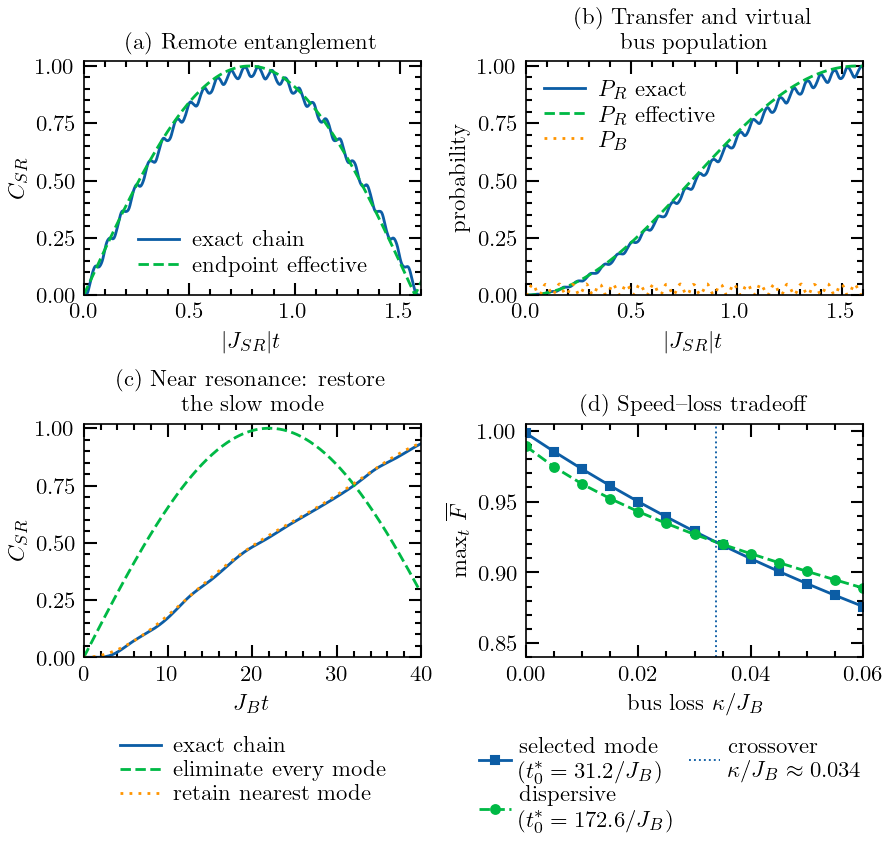

In [12]:
# Compact manuscript figure at exactly 150 mm width.
# Manual margins maximize the axes area while reserving only the space needed
# by labels and the panel-(c) legend. Typography and line widths follow N08.
fig = plt.figure(figsize=(FIG_WIDTH_150MM, 5.80))
gs = fig.add_gridspec(
    2, 2,
    left=0.105, right=0.985, bottom=0.24, top=0.925,
    hspace=0.55, wspace=0.31,
)

# (a) Remote entanglement
ax = fig.add_subplot(gs[0, 0])
ax.plot(scaled, C_full, label="exact chain")
ax.plot(scaled, C_end, "--", label="endpoint effective")
ax.set(
    xlabel=r"$|J_{SR}|t$",
    ylabel=r"$C_{SR}$",
    title="(a) Remote entanglement",
    xlim=(0, 1.60),
    ylim=(0, 1.02),
)
ax.legend(
    frameon=False, loc="lower center",
    handlelength=1.8, handletextpad=0.55, labelspacing=0.22,
    borderaxespad=0.40,
)

# (b) Transfer and virtual bus population
ax = fig.add_subplot(gs[0, 1])
ax.plot(scaled, P_R_full, label=r"$P_R$ exact")
ax.plot(scaled, P_R_end, "--", label=r"$P_R$ effective")
ax.plot(scaled, P_bus_full, linestyle=(0, (1.0, 2.2)), label=r"$P_B$")
ax.set(
    xlabel=r"$|J_{SR}|t$",
    ylabel="probability",
    title="(b) Transfer and virtual\nbus population",
    xlim=(0, 1.60),
    ylim=(0, 1.02),
)
ax.legend(
    frameon=False, loc="upper left",
    handlelength=1.8, handletextpad=0.55, labelspacing=0.22,
    borderaxespad=0.40,
)

# (c) Near resonance: restore the slow mode
ax = fig.add_subplot(gs[1, 0])
mask_res = t_res <= 40
ax.plot(t_res[mask_res], C_full_res[mask_res], label="exact chain")
ax.plot(t_res[mask_res], C_end_res[mask_res], "--", label="eliminate every mode")
ax.plot(
    t_res[mask_res], C_sel_res[mask_res],
    linestyle=(0, (1.0, 2.2)), label="retain nearest mode",
)
ax.set(
    xlabel=r"$J_B t$",
    ylabel=r"$C_{SR}$",
    title="(c) Near resonance: restore\nthe slow mode",
    xlim=(0, 40),
    ylim=(0, 1.02),
)
# Panel (c) has relevant curves over essentially the full data region, so the
# legend is placed below the axes instead of covering them.
ax.legend(
    frameon=False, loc="upper center", bbox_to_anchor=(0.50, -0.30),
    handlelength=1.8, handletextpad=0.55, labelspacing=0.16,
    borderaxespad=0.0,
)

# (d) Speed-loss tradeoff
ax = fig.add_subplot(gs[1, 1])
ax.plot(
    kappa_values, F_res_loss, "s-",
    label="selected mode\n" + fr"($t_0^*={t_res_loss:.1f}/J_B$)",
)
ax.plot(
    kappa_values, F_disp_loss, "o--",
    label="dispersive\n" + fr"($t_0^*={t_disp_loss:.1f}/J_B$)",
)
if np.isfinite(kappa_cross):
    ax.axvline(
        kappa_cross, lw=0.9, ls=":",
        label="crossover\n" + fr"$\kappa/J_B\approx{kappa_cross:.3f}$",
    )
ax.set(
    xlabel=r"bus loss $\kappa/J_B$",
    ylabel=r"$\max_t\,\overline{F}$",
    title="(d) Speed--loss tradeoff",
    xlim=(0.0, 0.060),
    ylim=(0.84, 1.005),
)
ax.legend(
    frameon=False, loc="upper center", bbox_to_anchor=(0.43, -0.30),
    ncol=2,
    handlelength=1.4, handletextpad=0.35, columnspacing=0.55,
    labelspacing=0.10, borderaxespad=0.0,
)

save_figure(fig, "N02_MF2", manuscript=True)
plt.show()
plt.close(fig)


**Manuscript Figure N02_MF2. Physical diagnostics for a spin-chain quantum bus.**
(a) Exact and endpoint-effective sender-receiver concurrence in the all-mode dispersive regime. (b) Receiver population and the small but nonzero bus occupation. (c) Close to a bus pole, eliminating every mode gives the wrong entanglement dynamics, while retaining the nearest mode repairs the reduced model. (d) Maximum phase-corrected average transfer fidelity versus bus loss for representative controlled dispersive and selected-mode implementations. The selected-mode protocol is faster and wins when endpoint lifetime is the limiting resource; the dispersive protocol overtakes when bus loss dominates. A small endpoint-loss rate is included in both.

**Notebook Figure N02_F3. Protocol-dependent loss exposure.** The selected-mode protocol reaches its closed-system transfer maximum much sooner and therefore suffers less endpoint damping at weak bus loss. Its real bus occupation makes it degrade more rapidly with increasing $\kappa$, producing the crossover shown in the scan.

## 10. Bus preparation, channel structure, and particle statistics

The polarized one-excitation sector is the cleanest derivation, but it is not the only operational setting.

- **Initialization-free protocols** change the endpoint encoding and decoding so that unknown chain parity or Jordan-Wigner strings do not corrupt the logical qubit.
- **Thermal finite chains** are not automatically Markovian reservoirs. If their correlations and recurrences are resolved, the appropriate endpoint object is a finite-time channel rather than a time-independent master equation.
- **Disorder** changes endpoint weights, mode isolation, and interference. Population and concurrence should be tracked separately.
- **Bosonic buses** share the same one-particle spectrum as the XX chain in the vacuum sector, but finite occupation produces the matrix element $\sqrt{n+1}$ rather than Pauli blocking.

The low-density bosonic approximation to a polarized spin chain is therefore controlled; it is not a generic replacement for a thermal spin bus.


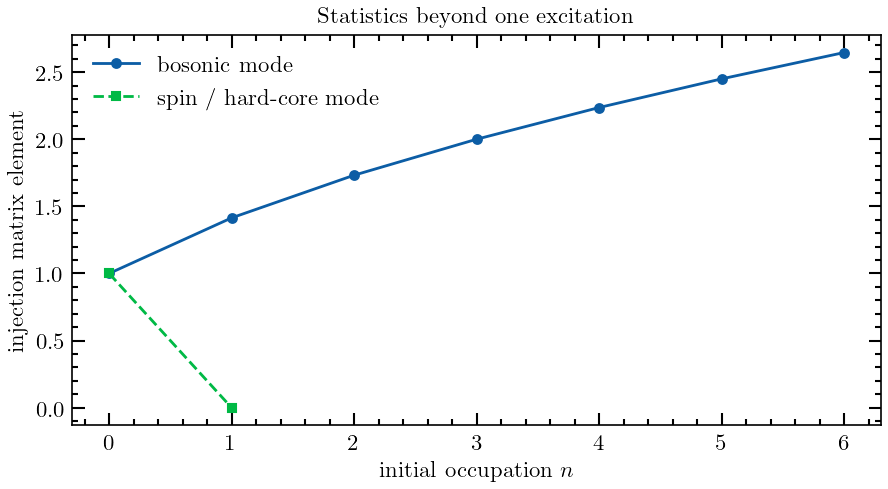

In [13]:
N_boson = 8
a_boson = destroy(N_boson)
spin_raise = qt.sigmap()

n_values = np.arange(0, N_boson - 1)
bosonic_matrix_elements = np.array([
    abs((basis(N_boson, n + 1).dag() * a_boson.dag() * basis(N_boson, n)))
    for n in n_values
], dtype=float)
spin_matrix_elements = np.full(len(n_values), np.nan, dtype=float)
spin_matrix_elements[0] = (spin_raise * G).norm()
spin_matrix_elements[1] = (spin_raise * E).norm()

statistics = pd.DataFrame({
    "occupation_n": n_values,
    "bosonic_injection_matrix_element": bosonic_matrix_elements,
    "spin_injection_matrix_element": spin_matrix_elements,
})
save_table(statistics, "N02_D9")

fig, ax = plt.subplots(figsize=(FIG_WIDTH_150MM, 3.25), constrained_layout=True)
ax.plot(n_values, bosonic_matrix_elements, "o-", label="bosonic mode")
ax.plot([0, 1], [1, 0], "s--", label="spin / hard-core mode")
ax.set(xlabel="initial occupation $n$", ylabel="injection matrix element", title="Statistics beyond one excitation")
ax.legend(frameon=False)
save_figure(fig, "N02_F4")
plt.show()
plt.close(fig)


**Figure N02_F4.** Statistics beyond the one-excitation sector. A bosonic mode exhibits the stimulated factor $\sqrt{n+1}$, whereas a spin or hard-core mode blocks a second excitation.


### 10.1 Thermal preparation as a finite-time transfer channel

The one-excitation calculation assumes that the bus begins in its vacuum. At finite temperature the receiver is described more naturally by a channel from the sender qubit to the receiver qubit. This calculation constructs that channel from the exact four-spin propagator, checks trace preservation and Choi positivity, and shows how thermal bus excitations reduce the best phase-corrected transfer fidelity. The effective description must therefore specify the bus reference state as part of its encoding map.

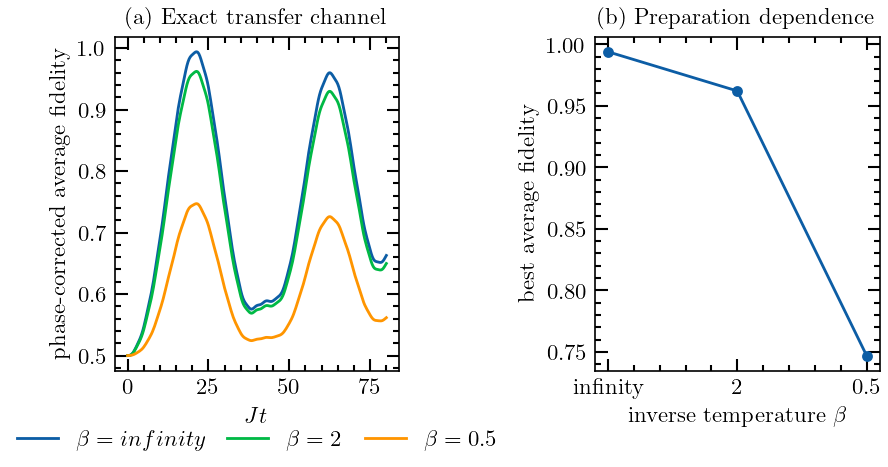

,beta,best_time,maximum_average_fidelity,maximum_trace_preservation_residual,minimum_choi_eigenvalue
0,infinity,21.333333,0.993940,0.0,-1.292369e-16
1,2,21.333333,0.962066,0.0,0.000000e+00
2,0.5,21.333333,0.746961,0.0,0.000000e+00


In [14]:
# Exact sender-to-receiver channels for a two-spin bus.
from itertools import product

E2, G2 = basis(2, 0), basis(2, 1)
sp2, sm2 = qt.sigmap(), qt.sigmam()
n2 = sp2 * sm2
I2 = qeye(2)

def op_on_site(operator, site, sites=4):
    factors = [I2] * sites
    factors[site] = operator
    return tensor(factors)

omega_bus_channel = 2.5
J_bus_channel = 1.0
omega_endpoint_channel = omega_bus_channel - J_bus_channel
g_channel = 0.15

nS, n1, n2b, nR = [op_on_site(n2, site) for site in range(4)]
spS, sp1, sp2b, spR = [op_on_site(sp2, site) for site in range(4)]
smS, sm1, sm2b, smR = [op_on_site(sm2, site) for site in range(4)]
H_channel = (
    omega_endpoint_channel * (nS + nR)
    + omega_bus_channel * (n1 + n2b)
    + J_bus_channel * (sp1 * sm2b + sm1 * sp2b)
    + g_channel * (spS * sm1 + smS * sp1 + spR * sm2b + smR * sp2b)
)
channel_energies, channel_states = H_channel.eigenstates()
channel_vectors = np.column_stack([state.full().ravel() for state in channel_states])

H_bus_channel = omega_bus_channel * (tensor(n2, I2) + tensor(I2, n2)) \
    + J_bus_channel * (tensor(sp2, sm2) + tensor(sm2, sp2))

def bus_reference(beta):
    if np.isinf(beta):
        return tensor(G2, G2).proj()
    rho = (-beta * H_bus_channel).expm()
    return rho / rho.tr()

receiver_ground = G2.proj()
operator_basis = {(i, j): basis(2, i) * basis(2, j).dag() for i, j in product(range(2), repeat=2)}
test_kets = [E2, G2, (E2 + G2).unit(), (E2 - G2).unit(), (E2 + 1j * G2).unit(), (E2 - 1j * G2).unit()]

def exact_transfer_channel(time, beta):
    phases = np.exp(-1j * np.asarray(channel_energies) * time)
    U_array = channel_vectors @ np.diag(phases) @ channel_vectors.conj().T
    U = Qobj(U_array, dims=H_channel.dims)
    outputs = {}
    rho_bus = bus_reference(beta)
    for key, sender_operator in operator_basis.items():
        rho0 = tensor(sender_operator, rho_bus, receiver_ground)
        outputs[key] = (U * rho0 * U.dag()).ptrace(3)
    coherence = outputs[(0, 1)].full()[0, 1]
    phase = float(np.angle(coherence)) if abs(coherence) > 1e-14 else 0.0
    correction = Qobj(np.diag([1.0, np.exp(1j * phase)]))
    corrected = {key: correction * value * correction.dag() for key, value in outputs.items()}
    choi = sum((tensor(operator_basis[key], corrected[key]) for key in operator_basis), 0 * tensor(I2, I2)) / 2.0
    tp_residual = (choi.ptrace(0) - I2 / 2.0).norm()
    min_choi = float(np.min(np.linalg.eigvalsh(choi.full())).real)
    fidelities = []
    for state in test_kets:
        rho_in = state.proj()
        rho_out = sum((rho_in.full()[i, j] * corrected[(i, j)] for i, j in product(range(2), repeat=2)), 0 * I2)
        fidelities.append(float(np.real((rho_in * rho_out).tr())))
    return float(np.mean(fidelities)), tp_residual, min_choi

channel_times = np.linspace(0.0, 80.0, 241)
beta_values = [np.inf, 2.0, 0.5]
channel_rows = []
channel_summary_rows = []
for beta in beta_values:
    values = np.array([exact_transfer_channel(time, beta) for time in channel_times])
    best = int(np.argmax(values[:, 0]))
    label = "infinity" if np.isinf(beta) else f"{beta:g}"
    for time, (average_fidelity, tp_residual, min_choi) in zip(channel_times, values):
        channel_rows.append((label, time, average_fidelity, tp_residual, min_choi))
    channel_summary_rows.append((label, channel_times[best], values[best, 0], values[:, 1].max(), values[:, 2].min()))

channel_data = pd.DataFrame(channel_rows, columns=["beta", "time", "average_fidelity", "trace_preservation_residual", "minimum_choi_eigenvalue"])
channel_summary = pd.DataFrame(channel_summary_rows, columns=["beta", "best_time", "maximum_average_fidelity", "maximum_trace_preservation_residual", "minimum_choi_eigenvalue"])
save_table(channel_data, "N02_D12")
save_table(channel_summary, "N02_D12_summary")

fig, axes = plt.subplots(1, 2, figsize=(FIG_WIDTH_150MM, 3.10), constrained_layout=True)

for beta in beta_values:
    label = "infinity" if np.isinf(beta) else f"{beta:g}"
    rows = channel_data[channel_data.beta == label]
    axes[0].plot(rows.time, rows.average_fidelity, label=fr"$\beta={label}$")

axes[0].set(
    xlabel=r"$Jt$",
    ylabel="phase-corrected average fidelity",
    title="(a) Exact transfer channel"
)
axes[0].legend(
    loc="upper center",
    bbox_to_anchor=(0.5, -0.15),
    frameon=False,
    ncol=3,
    handlelength=1.8,
    columnspacing=1.0,
    labelspacing=0.20,
    borderaxespad=0.0,
)

axes[1].plot(channel_summary.beta, channel_summary.maximum_average_fidelity, "o-")
axes[1].set(
    xlabel=r"inverse temperature $\beta$",
    ylabel="best average fidelity",
    title="(b) Preparation dependence"
)

save_figure(fig, "N02_F6")
plt.show()
plt.close(fig)

assert channel_summary.maximum_trace_preservation_residual.max() < 1e-10
assert channel_summary.minimum_choi_eigenvalue.min() > -1e-10
assert channel_summary.maximum_average_fidelity.iloc[0] > 0.95
assert channel_summary.maximum_average_fidelity.iloc[-1] < channel_summary.maximum_average_fidelity.iloc[0]
display(channel_summary)

## 11. Validity map and first structural failure

A controlled reduction should record

$$
\eta_{\max}=\max_{\nu,k}\left|\frac{g_{\nu,k}}{\Delta_{\nu,k}}\right|,
\qquad
\Lambda_\nu=\sum_k\left|\frac{g_{\nu,k}}{\Delta_{\nu,k}}\right|^2,
$$

$$
\Delta_{\min}=\min_{\nu,k}|\Delta_{\nu,k}|,
\qquad
\delta_{\rm iso}=\min_{k\neq k_0}|\varepsilon_k-\varepsilon_{k_0}|.
$$

The first quantity detects one dangerous mode, the second cumulative dressing, and the third spectral crowding. A selected-mode model additionally requires the retained coupling to remain small relative to $\delta_{\rm iso}$.

The first repair is structural:

- one dangerous pole $\rightarrow$ retain that mode;
- nearby poles $\rightarrow$ retain the cluster;
- an unknown or excited bus $\rightarrow$ change the encoding or use the finite-time channel;
- strong bus interactions $\rightarrow$ replace the single-particle mode sum by the appropriate many-body boundary response.


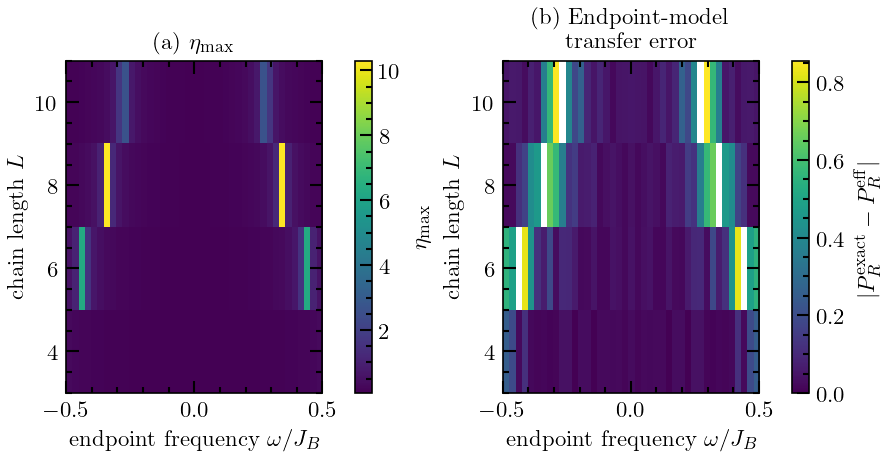

In [15]:
L_values = np.array([4, 6, 8, 10])
omega_values = np.linspace(-0.50, 0.50, 41)
eta_map = np.zeros((len(L_values), len(omega_values)))
error_map = np.zeros_like(eta_map)

for i, L_scan in enumerate(L_values):
    for j, omega_scan in enumerate(omega_values):
        H_scan, kets_scan = one_excitation_model(
            L_scan, 1.0, 0.0, omega_scan, omega_scan, 0.06, 0.06
        )
        H_eff_scan, d_scan = endpoint_effective(
            L_scan, 1.0, 0.0, omega_scan, omega_scan, 0.06, 0.06
        )
        eta = max(
            np.max(np.abs(d_scan["g_sk"] / d_scan["delta_s_k"])),
            np.max(np.abs(d_scan["g_rk"] / d_scan["delta_r_k"])),
        )
        eta_map[i, j] = eta
        J_eff = abs(d_scan["J_sr"])
        if not np.isfinite(J_eff) or J_eff < 1e-8 or eta > 2:
            error_map[i, j] = np.nan
            continue
        t_pi = np.pi / (2 * J_eff)
        psi_exact = (-1j * H_scan * t_pi).expm() * basis(L_scan + 2, 0)
        psi_eff = (-1j * H_eff_scan * t_pi).expm() * basis(2, 0)
        P_exact = abs(kets_scan[-1].overlap(psi_exact)) ** 2
        P_eff = abs(psi_eff.full().ravel()[1]) ** 2
        error_map[i, j] = abs(P_exact - P_eff)

save_table(pd.DataFrame([
    {"L": L_scan, "omega_endpoint": omega, "eta_max": eta_map[i, j], "transfer_error": error_map[i, j]}
    for i, L_scan in enumerate(L_values)
    for j, omega in enumerate(omega_values)
]), "N02_D10")

fig, axes = plt.subplots(1, 2, figsize=(FIG_WIDTH_150MM, 3.05), constrained_layout=True)
extent = [omega_values[0], omega_values[-1], L_values[0] - 1, L_values[-1] + 1]
im0 = axes[0].imshow(eta_map, origin="lower", aspect="auto", extent=extent)
axes[0].set(xlabel=r"endpoint frequency $\omega/J_B$", ylabel="chain length $L$", title=r"(a) $\eta_{\max}$")
fig.colorbar(im0, ax=axes[0], label=r"$\eta_{\max}$")
im1 = axes[1].imshow(error_map, origin="lower", aspect="auto", extent=extent, vmin=0)
axes[1].set(xlabel=r"endpoint frequency $\omega/J_B$", ylabel="chain length $L$", title="(b) Endpoint-model\ntransfer error")
fig.colorbar(im1, ax=axes[1], label=r"$|P_R^{\rm exact}-P_R^{\rm eff}|$")
save_figure(fig, "N02_F5")
plt.show()
plt.close(fig)


**Figure N02_F5.** Validity and structural failure across chain length and endpoint frequency. Increasing spectral crowding brings poles into the observation window, increases the local dispersive parameter, and eventually invalidates all-mode elimination.


## 12. Method comparison

| Method | Operational step | Physical information made explicit | Failure signal |
|---|---|---|---|
| normal modes + small rotation | diagonalize the bus and rotate away each off-resonant mode | parity, signed path interference, shifts, virtual profile | one $\lvert g_{\nu k}/\Delta_{\nu k}\rvert$ becomes large |
| projection / resolvent | evaluate the boundary self-energy | poles, energy dependence, interacting-bus extension, mode-cluster repair | a pole enters the observation window |
| complex self-energy | include bus loss in the resolvent | coherent exchange and local or correlated induced decay from one response | the memory kernel varies on the endpoint time scale |
| exact QuTiP propagation | evolve the complete spin or invariant-sector model | concurrence, channel fidelity, bus occupation, recurrence | accurate but not explanatory by itself |

The small rotation is the most transparent starting point for the quadratic chain. The resolvent is its structural completion, not a competing answer. Exact propagation is the independent benchmark used to test the retained space.


## 13. Numerical validation

The final cell checks the exact excitation symmetry, analytic mode structure,
the controlled dispersive regime, the selected-mode repair, the
complex-coupling bright/dark convention, the tensor-versus-invariant-sector
equivalence, and the finite numerical outputs used in the figures.

In [16]:
# Exact tensor-product versus one-excitation-sector validation.
# Structural identities use machine-precision gates; independent solver
# trajectories use tolerances consistent with the ODE settings.

H_sector, sector_kets = one_excitation_model(
    L, J, omega_b, omega_s, omega_r, g_s, g_r
)
site_kets_full = [one_excitation_site_state(j, L + 2) for j in range(L + 2)]

H_projected_array = np.array([
    [H_full.matrix_element(site_kets_full[i].dag(), site_kets_full[j]) for j in range(L + 2)]
    for i in range(L + 2)
], dtype=complex)
H_projected = Qobj(H_projected_array, dims=[[L + 2], [L + 2]])
sector_hamiltonian_residual = (H_projected - H_sector).norm()

probe_times = np.linspace(0, 0.8 * t_transfer, 9)
sector_result = sesolve(H_sector, basis(L + 2, 0), probe_times, options=SOLVER)
tensor_result = sesolve(H_full, psi_full, probe_times, options=SOLVER)
sector_receiver = np.array([abs(sector_kets[-1].overlap(state)) ** 2 for state in sector_result.states])
tensor_receiver = np.asarray(expect(n_receiver, tensor_result.states), dtype=float)
sector_dynamic_residual = np.max(np.abs(sector_receiver - tensor_receiver))

min_gamma_eigenvalue = response["smallest_decay_eigenvalue"].min()
# Complex-coupling check of the selected-mode bright/dark convention.
g_s_complex = g_res * np.exp(0.37j)
g_r_complex = 0.75 * g_res * np.exp(-0.52j)

H_sel_complex, selected_complex = selected_mode_effective(
    L_res,
    J,
    omega_b,
    omega_res,
    omega_res,
    g_s_complex,
    g_r_complex,
    k0,
)

g_s_k0_complex = selected_complex["g_sk"][k0]
g_r_k0_complex = selected_complex["g_rk"][k0]
g_b_complex = np.sqrt(
    abs(g_s_k0_complex) ** 2 + abs(g_r_k0_complex) ** 2
)

bright_complex = np.array(
    [g_s_k0_complex, g_r_k0_complex],
    dtype=complex,
) / g_b_complex

dark_complex = np.array(
    [np.conj(g_r_k0_complex), -np.conj(g_s_k0_complex)],
    dtype=complex,
) / g_b_complex

# In the [S, k0, R] basis, this row maps endpoint amplitudes
# into the selected-mode amplitude.
selected_mode_vertex = H_sel_complex.full()[1, [0, 2]]

complex_bright_dark_residual = max(
    abs(selected_mode_vertex @ bright_complex - g_b_complex),
    abs(selected_mode_vertex @ dark_complex),
    abs(np.vdot(bright_complex, dark_complex)),
    abs(np.vdot(bright_complex, bright_complex) - 1.0),
    abs(np.vdot(dark_complex, dark_complex) - 1.0),
)
validation = pd.DataFrame({
    "check": [
        "excitation symmetry",
        "analytic spectrum",
        "endpoint parity",
        "sector Hamiltonian projection",
        "sector dynamics",
        "dispersive bus occupation",
        "dispersive endpoint distance",
        "selected-mode repair",
        "complex bright-dark convention",
        "passive decay-matrix positivity",
        "finite validity map",
        "closed transfer maxima interior",
        "selected mode wins at weak bus loss",
        "dispersive protocol wins at strong bus loss",
        "finite loss crossover",
    ],
    "value": [
        algebra.loc[algebra.quantity == "excitation_commutator_norm", "value"].iloc[0],
        algebra.loc[algebra.quantity == "spectrum_residual", "value"].iloc[0],
        algebra.loc[algebra.quantity == "endpoint_parity_residual", "value"].iloc[0],
        sector_hamiltonian_residual,
        sector_dynamic_residual,
        P_bus_full.max(),
        D_end.max(),
        rmse_selected / rmse_endpoint,
        complex_bright_dark_residual,
        min_gamma_eigenvalue,
        np.any(np.isfinite(error_map)),
        (t_disp_loss > 0) and (t_res_loss > 0),
        F_res_loss[0] - F_disp_loss[0],
        F_disp_loss[-1] - F_res_loss[-1],
        kappa_cross,
    ],
})
save_table(validation, "N02_D11")

assert validation.iloc[0, 1] < 1e-12
assert validation.iloc[1, 1] < 1e-12
assert validation.iloc[2, 1] < 1e-12
assert sector_hamiltonian_residual < 1e-12
assert sector_dynamic_residual < 5e-6
assert P_bus_full.max() < 0.08
assert D_end.max() < 0.15
assert rmse_selected < 0.10 * rmse_endpoint
assert complex_bright_dark_residual < 1e-12
assert min_gamma_eigenvalue > -1e-10
assert np.any(np.isfinite(error_map))
assert t_disp_loss > 0 and t_res_loss > 0
assert Pmax_disp_closed > 0.98 and Pmax_res_closed > 0.98
assert F_res_loss[0] > F_disp_loss[0]
assert F_disp_loss[-1] > F_res_loss[-1]
assert np.isfinite(kappa_cross)

validation

,check,value
0,excitation symmetry,0.0
1,analytic spectrum,0.0
2,endpoint parity,0.0
3,sector Hamiltonian projection,0.0
4,sector dynamics,0.0
5,dispersive bus occupation,0.048951
6,dispersive endpoint distance,0.059325
7,selected-mode repair,0.016598
8,complex bright-dark convention,0.0
9,passive decay-matrix positivity,0.000013


## 14. Exercises and extensions

1. Derive the open-chain eigenvalues and mode functions analytically.
2. Prove $\phi_k(L)=(-1)^{k+1}\phi_k(1)$ and determine how chain parity changes the sign of $J_{SR}$.
3. Derive the small-rotation generator and recover the symmetrized exchange denominator.
4. Start with the sender entangled with an external reference and verify entanglement transfer to the receiver using `ptrace` and `concurrence`.
5. Introduce a controlled phase error and compare receiver population with average qubit-transfer fidelity.
6. Diagonalize $\Gamma(E)$ and identify local and collective endpoint jumps.
7. Add diagonal disorder and compare the robustness of the dispersive and selected-mode protocols.
8. Retain two neighbouring modes and determine when the three-state model becomes insufficient.
9. Implement an initialization-free two-spin encoding and track the finite-time endpoint channel.
10. Replace the spin chain by a bosonic chain and verify the $\sqrt{n+1}$ enhancement.
11. Use two separated bus modes as coloured channels for two simultaneous sender-receiver pairs.
12. Replace the uniform bus by an interacting chain and compute its boundary response numerically.


## References

### Spin-chain transfer and retained-space physics

1. S. Bose, “Quantum communication through an unmodulated spin chain,” *Phys. Rev. Lett.* **91**, 207901 (2003). [DOI](https://doi.org/10.1103/PhysRevLett.91.207901)
2. M. Christandl, N. Datta, A. Ekert, and A. J. Landahl, “Perfect state transfer in quantum spin networks,” *Phys. Rev. Lett.* **92**, 187902 (2004). [DOI](https://doi.org/10.1103/PhysRevLett.92.187902)
3. A. Wójcik, T. Łuczak, P. Kurzyński, A. Grudka, T. Gdala, and M. Bednarska, “Unmodulated spin chains as universal quantum wires,” *Phys. Rev. A* **72**, 034303 (2005). [DOI](https://doi.org/10.1103/PhysRevA.72.034303)
4. G. D. de Moraes Neto, M. A. de Ponte, and M. H. Y. Moussa, “Engineering interactions for quasiperfect transfer of polariton states through nonideal bosonic networks of distinct topologies,” *Phys. Rev. A* **84**, 032339 (2011). [DOI](https://doi.org/10.1103/PhysRevA.84.032339)
5. G. D. M. Neto, M. A. de Ponte, and M. H. Y. Moussa, “Nonlocal dissipative tunneling for high-fidelity quantum-state transfer between distant parties,” *Phys. Rev. A* **85**, 052303 (2012). [DOI](https://doi.org/10.1103/PhysRevA.85.052303)
6. G. M. A. Almeida, “Interplay between speed and fidelity in off-resonant quantum-state transfer,” *Phys. Rev. A* **98**, 012334 (2018). [DOI](https://doi.org/10.1103/PhysRevA.98.012334)
7. S. Oh, L.-A. Wu, Y.-P. Shim, J. Fei, M. Friesen, and X. Hu, “Heisenberg spin bus as a robust transmission line for quantum-state transfer,” *Phys. Rev. A* **84**, 022330 (2011). [DOI](https://doi.org/10.1103/PhysRevA.84.022330)
8. S. Lorenzo, T. J. G. Apollaro, A. Sindona, and F. Plastina, “Quantum-state transfer via resonant tunneling through local-field-induced barriers,” *Phys. Rev. A* **87**, 042313 (2013). [DOI](https://doi.org/10.1103/PhysRevA.87.042313)
9. S. Paganelli, S. Lorenzo, T. J. G. Apollaro, F. Plastina, and G. L. Giorgi, “Routing quantum information in spin chains,” *Phys. Rev. A* **87**, 062309 (2013). [DOI](https://doi.org/10.1103/PhysRevA.87.062309)
10. A. Gratsea, G. M. Nikolopoulos, and P. Lambropoulos, “Photon-assisted quantum state transfer and entanglement generation in spin chains,” *Phys. Rev. A* **98**, 012304 (2018). [DOI](https://doi.org/10.1103/PhysRevA.98.012304)
11. L. Banchi, T. J. G. Apollaro, A. Cuccoli, R. Vaia, and P. Verrucchi, “Long quantum channels for high-quality entanglement transfer,” *Phys. Rev. A* **82**, 052321 (2010). [DOI](https://doi.org/10.1103/PhysRevA.82.052321)
12. C. Di Franco, M. Paternostro, and M. S. Kim, “Perfect state transfer on a spin chain without state initialization,” *Phys. Rev. Lett.* **101**, 230502 (2008). [DOI](https://doi.org/10.1103/PhysRevLett.101.230502)
13. N. Y. Yao *et al.*, “Robust quantum state transfer in random unpolarized spin chains,” *Phys. Rev. Lett.* **106**, 040505 (2011). [DOI](https://doi.org/10.1103/PhysRevLett.106.040505)
14. Y. P. Kandel *et al.*, “Adiabatic quantum state transfer in a semiconductor quantum-dot spin chain,” *Nat. Commun.* **12**, 2156 (2021). [DOI](https://doi.org/10.1038/s41467-021-22416-5)
15. L. Xiang *et al.*, “Enhanced quantum state transfer by circumventing quantum chaotic behavior,” *Nat. Commun.* **15**, 4918 (2024). [DOI](https://doi.org/10.1038/s41467-024-48791-3)
16. F. A. Roy *et al.*, “Parity-dependent state transfer for direct entanglement generation,” *Nat. Commun.* **16**, 2660 (2025). [DOI](https://doi.org/10.1038/s41467-025-57818-2)
17. G. D. de Moraes Neto, M. A. de Ponte, and M. H. Y. Moussa, “Colored channels for high-fidelity information transfer and processing between remote multi-branch quantum circuits,” *EPL* **103**, 43001 (2013). [DOI](https://doi.org/10.1209/0295-5075/103/43001)
18. E. K. Soares, G. D. de Moraes Neto, and F. M. Andrade, *Entropy* **27**, 764 (2025). [DOI](https://doi.org/10.3390/e27070764)

### QuTiP

19. J. R. Johansson, P. D. Nation, and F. Nori, “QuTiP 2: A Python framework for the dynamics of open quantum systems,” *Comput. Phys. Commun.* **184**, 1234 (2013).
20. N. Lambert *et al.*, “QuTiP 5: The Quantum Toolbox in Python,” *Phys. Rep.* **1153**, 1 (2025). [DOI](https://doi.org/10.1016/j.physrep.2025.07.004)

In [17]:
environment = {
    "python": sys.version,
    "qutip": qt.__version__,
    "numpy": np.__version__,
    "pandas": pd.__version__,
    "matplotlib": plt.matplotlib.__version__,
    "scienceplots": scienceplots.__version__ if hasattr(scienceplots, "__version__") else "installed",
    "platform": platform.platform(),
    "notebook": "N02",
}
(DATA_DIR / "N02_environment.json").write_text(json.dumps(environment, indent=2), encoding="utf-8")
environment

{'python': '3.11.9 (tags/v3.11.9:de54cf5, Apr  2 2024, 10:12:12) [MSC v.1938 64 bit (AMD64)]',
 'qutip': '5.2.0',
 'numpy': '2.3.2',
 'pandas': '3.0.6',
 'matplotlib': '3.10.5',
 'scienceplots': 'installed',
 'platform': 'Windows-10-10.0.26200-SP0',
 'notebook': 'N02'}